,side,real_kpc,model_kpc,difference_kpc,relative_error_percent
0,left,218.668345,219.789411,1.121066,0.512679
1,right,227.634221,226.513155,-1.121066,-0.492486
2,mean,223.151283,223.151283,0.000000,0.000000


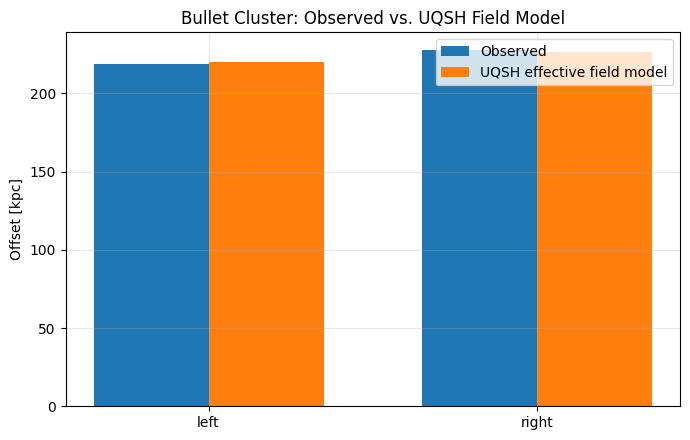

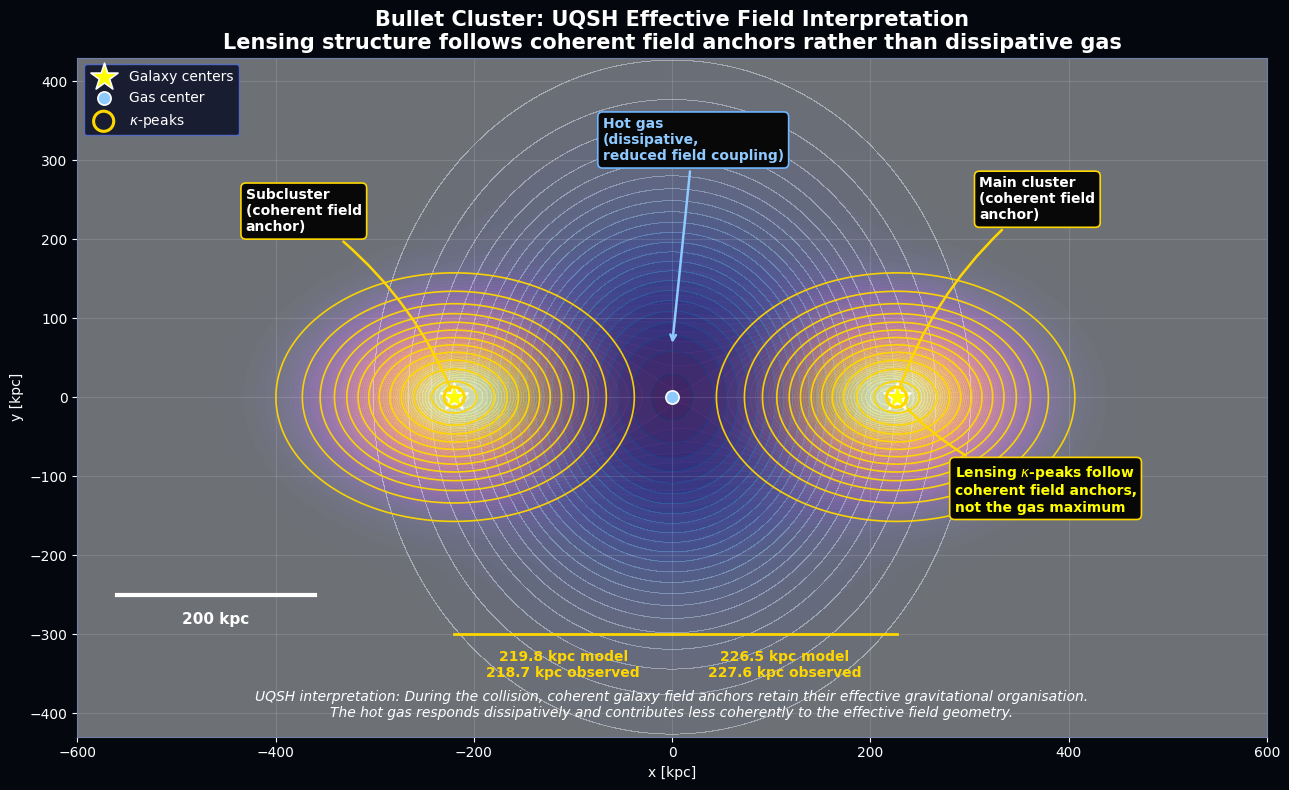

Generated files:
bullet_cluster_comparison.csv
fig_bullet_offsets.png
fig_bullet_offsets_uqsh_field.png

Summary:
Observed mean offset: 223.2 kpc
UQSH model mean offset: 223.2 kpc
Mean difference: 0.00 kpc
Left relative error: 0.51%
Right relative error: -0.49%


In [4]:
# ============================================================
# Bullet Cluster UQSH Reproduction Notebook
# Author: Ukshin Q. Rexhepi
# Purpose:
# Reproduce the Bullet Cluster offset comparison and the
# UQSH effective field interpretation figure.
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# 1. Observed and modelled offset data
# ------------------------------------------------------------

real_left_kpc = 218.6683445875933
real_right_kpc = 227.63422142504444
real_mean_kpc = 223.15128300631886

model_left_kpc = 219.7894110378616
model_right_kpc = 226.5131549747761
model_mean_kpc = 223.15128300631886

df = pd.DataFrame({
    "side": ["left", "right", "mean"],
    "real_kpc": [real_left_kpc, real_right_kpc, real_mean_kpc],
    "model_kpc": [model_left_kpc, model_right_kpc, model_mean_kpc]
})

df["difference_kpc"] = df["model_kpc"] - df["real_kpc"]
df["relative_error_percent"] = 100 * df["difference_kpc"] / df["real_kpc"]

display(df)

df.to_csv("bullet_cluster_comparison.csv", index=False)

# ------------------------------------------------------------
# 2. Figure 1: Observed vs. UQSH model offsets
# ------------------------------------------------------------

plot_df = df[df["side"].isin(["left", "right"])].copy()

labels = plot_df["side"].tolist()
real_vals = plot_df["real_kpc"].to_numpy()
model_vals = plot_df["model_kpc"].to_numpy()

x = np.arange(len(labels))
width = 0.35

plt.figure(figsize=(7, 4.5))
plt.bar(x - width/2, real_vals, width, label="Observed")
plt.bar(x + width/2, model_vals, width, label="UQSH effective field model")

plt.ylabel("Offset [kpc]")
plt.title("Bullet Cluster: Observed vs. UQSH Field Model")
plt.xticks(x, labels)
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.savefig("fig_bullet_offsets.png", dpi=300, bbox_inches="tight")
plt.show()

# ------------------------------------------------------------
# 3. Figure 2: UQSH effective field interpretation
# ------------------------------------------------------------

left_real = real_left_kpc
right_real = real_right_kpc
left_model = model_left_kpc
right_model = model_right_kpc

gal_left = -left_model
gal_right = right_model
gas_x = 0.0

x = np.linspace(-600, 600, 700)
y = np.linspace(-430, 430, 500)
X, Y = np.meshgrid(x, y)

def gaussian(x0, y0, sx, sy, amp):
    return amp * np.exp(
        -(((X - x0)**2) / (2 * sx**2) + ((Y - y0)**2) / (2 * sy**2))
    )

phi_gal = (
    gaussian(gal_left, 0, 80, 70, 1.0) +
    gaussian(gal_right, 0, 80, 70, 1.0)
)

phi_gas = gaussian(gas_x, 0, 120, 170, 0.35)
phi_total = phi_gal + phi_gas

fig, ax = plt.subplots(figsize=(13, 8), facecolor="#05070f")
ax.set_facecolor("#05070f")

ax.contourf(X, Y, phi_total, levels=80, cmap="inferno", alpha=0.85)
ax.contourf(X, Y, phi_gas, levels=30, cmap="Blues", alpha=0.45)
ax.contour(X, Y, phi_gal, levels=12, colors="gold", linewidths=1.2, alpha=0.95)

ax.scatter([gal_left, gal_right], [0, 0], marker="*", s=420,
           color="yellow", edgecolor="white", linewidth=1.2,
           label="Galaxy centers", zorder=5)

ax.scatter([gas_x], [0], s=90, color="#8ec9ff",
           edgecolor="white", linewidth=1.2,
           label="Gas center", zorder=6)

ax.scatter([gal_left, gal_right], [0, 0], s=210,
           facecolors="none", edgecolors="gold", linewidth=2.2,
           label=r"$\kappa$-peaks", zorder=7)

# Scale bar
bar_x0 = -560
bar_y = -250
ax.plot([bar_x0, bar_x0 + 200], [bar_y, bar_y], color="white", lw=3)
ax.text(bar_x0 + 100, bar_y - 22, "200 kpc", color="white",
        ha="center", va="top", fontsize=11, fontweight="bold")

# Offset lines
offset_y = -300
ax.plot([gal_left, gas_x], [offset_y, offset_y], color="gold", lw=2)
ax.plot([gas_x, gal_right], [offset_y, offset_y], color="gold", lw=2)

ax.text((gal_left + gas_x)/2, offset_y - 20,
        f"{left_model:.1f} kpc model\n{left_real:.1f} kpc observed",
        color="gold", ha="center", va="top", fontsize=10, fontweight="bold")

ax.text((gas_x + gal_right)/2, offset_y - 20,
        f"{right_model:.1f} kpc model\n{right_real:.1f} kpc observed",
        color="gold", ha="center", va="top", fontsize=10, fontweight="bold")

bbox_yellow = dict(boxstyle="round,pad=0.35", fc="#080808", ec="gold", lw=1.2)
bbox_blue = dict(boxstyle="round,pad=0.35", fc="#080808", ec="#6fb6ff", lw=1.2)

ax.annotate("Subcluster\n(coherent field\nanchor)",
            xy=(gal_left, 0), xytext=(-430, 210),
            color="white", fontsize=10, fontweight="bold",
            bbox=bbox_yellow,
            arrowprops=dict(arrowstyle="->", color="gold", lw=1.8,
                            connectionstyle="arc3,rad=-0.15"))

ax.annotate("Main cluster\n(coherent field\nanchor)",
            xy=(gal_right, 0), xytext=(310, 225),
            color="white", fontsize=10, fontweight="bold",
            bbox=bbox_yellow,
            arrowprops=dict(arrowstyle="->", color="gold", lw=1.8,
                            connectionstyle="arc3,rad=0.15"))

ax.annotate("Hot gas\n(dissipative,\nreduced field coupling)",
            xy=(gas_x, 65), xytext=(-70, 300),
            color="#8ec9ff", fontsize=10, fontweight="bold",
            bbox=bbox_blue,
            arrowprops=dict(arrowstyle="->", color="#8ec9ff", lw=1.8))

ax.annotate("Lensing $\\kappa$-peaks follow\ncoherent field anchors,\nnot the gas maximum",
            xy=(gal_right, 0), xytext=(285, -145),
            color="yellow", fontsize=10, fontweight="bold",
            bbox=bbox_yellow,
            arrowprops=dict(arrowstyle="->", color="gold", lw=1.8,
                            connectionstyle="arc3,rad=-0.15"))

note = (
    "UQSH interpretation: During the collision, coherent galaxy field anchors retain their effective gravitational organisation.\n"
    "The hot gas responds dissipatively and contributes less coherently to the effective field geometry."
)

ax.text(0, -390, note, color="white", fontsize=10, fontstyle="italic",
        ha="center", va="center")

ax.set_title(
    "Bullet Cluster: UQSH Effective Field Interpretation\n"
    "Lensing structure follows coherent field anchors rather than dissipative gas",
    color="white", fontsize=15, fontweight="bold"
)

ax.set_xlabel("x [kpc]", color="white")
ax.set_ylabel("y [kpc]", color="white")

ax.set_xlim(-600, 600)
ax.set_ylim(-430, 430)

ax.tick_params(colors="white")
for spine in ax.spines.values():
    spine.set_color("#6f7fa6")

ax.grid(color="white", alpha=0.12)

legend = ax.legend(loc="upper left", facecolor="#10142a",
                   edgecolor="#5970c9", framealpha=0.9)
for text in legend.get_texts():
    text.set_color("white")

plt.tight_layout()
plt.savefig("fig_bullet_offsets_uqsh_field.png", dpi=300, bbox_inches="tight")
plt.show()

# ------------------------------------------------------------
# 4. Summary
# ------------------------------------------------------------

print("Generated files:")
print("bullet_cluster_comparison.csv")
print("fig_bullet_offsets.png")
print("fig_bullet_offsets_uqsh_field.png")

print("\nSummary:")
print(f"Observed mean offset: {real_mean_kpc:.1f} kpc")
print(f"UQSH model mean offset: {model_mean_kpc:.1f} kpc")
print(f"Mean difference: {model_mean_kpc - real_mean_kpc:.2f} kpc")
print(f"Left relative error: {df.loc[0, 'relative_error_percent']:.2f}%")
print(f"Right relative error: {df.loc[1, 'relative_error_percent']:.2f}%")